# O(3) Bubble Nucleation with Finite Chemical Potential

This notebook studies bubble nucleation in a scalar field theory with finite chemical potential. We consider a potential with two minima: a metastable minimum (false vacuum) and a stable minimum (true vacuum). The finite chemical potential introduces a term $-\frac{1}{2}\omega^2\phi^2$ that modifies the potential landscape.

The grand potential $\Omega(\phi) = V(\phi) - \frac{1}{2}\omega^2\phi^2$ governs the dynamics, where $V(\phi)$ is the underlying potential with two minima. The bubble nucleation solution describes the O(3)-symmetric tunneling from the metastable to the stable vacuum.

The workflow is:
1. Specify model parameters and visualize the grand potential $\Omega(\phi)$.
2. Identify the metastable and stable minima.
3. Solve for the O(3) bubble nucleation profile (bounce solution).
4. Compute the nucleation rate and suppression exponent.

This analysis extends the standard vacuum decay to include finite density effects through the chemical potential term.


## Configuration

All parameters are centralized here. Modify these values to explore different configurations.


In [32]:
# ============================================================================
# Configuration Section
# ============================================================================

import sys
from pathlib import Path

# Setup project path
PROJECT_ROOT = Path.cwd().resolve().parents[1]  # Points to directory containing Bubble_finder
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Model parameters for the potential from [reference]
# V(φ) = -1/2 + (φ - 1)² [2φ - 5 + (2 - φ)² log((2-φ)²(φ₀-1)²/((φ-1)²(φ₀-2)²))]
# This potential has a false minimum at φ = 1 and true minimum at φ = 2
# It admits a d=4 bounce solution with known analytical action for Q=0
PHI0 = 1.999       # Field value at center of bounce (for numerics)
V1 = 1.0          # False vacuum (metastable minimum)
V2 = 2.0          # True vacuum (stable minimum)

# Chemical potential (finite density parameter)
OMEGA = 0.5       # Chemical potential ω

# Grid parameters for future 2D ansatz
GRID_NR = 150     # Number of radial points
GRID_NTAU = 300   # Number of tau points
GRID_LR = 10.0    # Radial domain size

print(f"Configuration loaded:")
print(f"  Project root: {PROJECT_ROOT}")
print(f"  Model: Potential with false vacuum at φ={V1}, true vacuum at φ={V2}")
print(f"  φ₀ = {PHI0} (field value at center for numerics)")
print(f"  Chemical potential: ω = {OMEGA}")
print(f"  Tunneling: from φ={V1} (metastable) to φ={V2} (stable)")

Configuration loaded:
  Project root: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX
  Model: Potential with false vacuum at φ=1.0, true vacuum at φ=2.0
  φ₀ = 1.999 (field value at center for numerics)
  Chemical potential: ω = 0.5
  Tunneling: from φ=1.0 (metastable) to φ=2.0 (stable)


In [33]:
# ============================================================================
# Imports
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.special import spence  # For dilogarithm Li₂ (Li₂(z) = spence(1-z))

# Configure matplotlib for publication-quality figures
import matplotlib as mpl
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{siunitx}",
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 20,
})
plt.rcParams["figure.figsize"] = (7, 4.8)

print("Imports completed successfully.")


Imports completed successfully.


## Model Parameters and Grand Potential

We consider a scalar field theory with a specific potential that admits an analytical bounce solution for $d=4$ and $Q=0$. The underlying potential is:

$$V(\phi) = -\frac{1}{2} + (\phi - 1)^2 \left[ 2\phi - 5 + (2 - \phi)^2 \log \frac{(2 - \phi)^2 (\phi_0 - 1)^2}{(\phi - 1)^2 (\phi_0 - 2)^2} \right]$$

where $\phi_0$ is the field value at the center of the bounce (we take $\phi_0 = 1.999$ for numerics). This potential is valid for $\phi \in [1, 2]$ and has:
- **False vacuum** (metastable minimum) at $\phi = 1$
- **True vacuum** (stable minimum) at $\phi = 2$
- **Tunneling** occurs from $\phi = 1$ to $\phi = 2$

**Analytical Reference:**

For $Q = 0$ and $d=4$, the Euclidean action is known analytically:

$$S_0 = -\frac{\pi^2}{3} \left[ \phi_0 - 1 + \text{Li}_2 \left( \frac{\phi_0 - 1}{\phi_0 - 2} \right) \right]$$

where $\text{Li}_2$ is the dilogarithm function. This provides a benchmark for our numerical calculations.

**Finite Chemical Potential:**

The finite chemical potential $\omega$ modifies the potential through the term $-\frac{1}{2}\omega^2\phi^2$, giving the grand potential:

$$\Omega(\phi) = V(\phi) - \frac{1}{2}\omega^2\phi^2$$

The grand potential $\Omega(\phi)$ has minima that are shifted from $\phi = 1$ and $\phi = 2$ due to the $\omega^2$ term. The bubble nucleation solution describes the O(3)-symmetric tunneling from the metastable minimum (shifted from $\phi = 1$) to the stable minimum (shifted from $\phi = 2$) in this grand potential landscape.

**Why This Potential?**

This potential is particularly useful because:
1. It has a known analytical bounce action for $d=4$ and $Q=0$, allowing us to validate our numerical methods
2. It provides a non-trivial test case for studying finite density effects
3. The logarithmic structure makes it more challenging than polynomial potentials, testing the robustness of our numerical solver


Analytical Euclidean action (d=4, Q=0): S₀ = 80.590466
Minima of grand potential Ω(φ):
  False vacuum (metastable): φ = 1.006814, Ω = -0.625759
  True vacuum (stable):     φ = 2.080561, Ω = -2.020576
  Energy difference:        ΔΩ = 1.394817

Note: The underlying potential V(φ) has minima at v1=1.0 and v2=2.0.
      The grand potential Ω = V - 1/2 ω² φ² shifts these minima slightly.
      False vacuum is near v1=1.0 (shift: +0.0068)
      True vacuum is near v2=2.0 (shift: +0.0806)


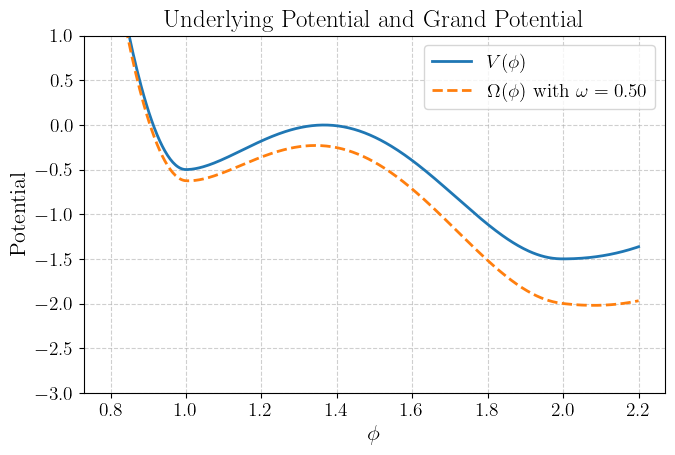

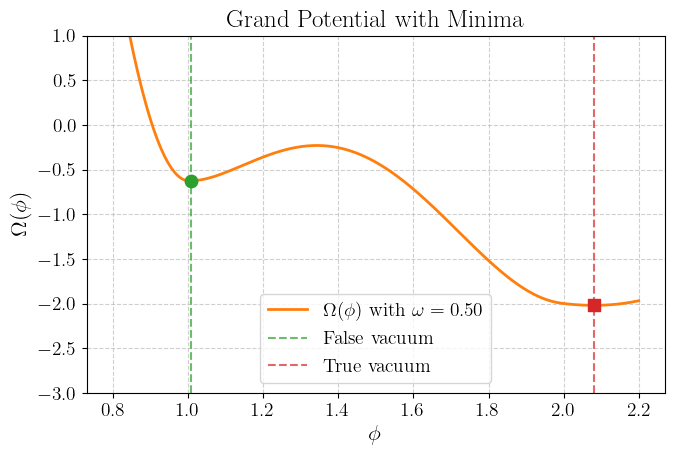

In [34]:
# Define the underlying potential V(φ)
def V_phi(phi, phi0, v1, v2):
    """
    Underlying potential: V(φ) = -1/2 + (φ - 1)² [2φ - 5 + (2 - φ)² log((2-φ)²(φ₀-1)²/((φ-1)²(φ₀-2)²))]
    This potential has false minimum at φ = v1 = 1 and true minimum at φ = v2 = 2
    Valid for φ in [v1, v2] = [1, 2]
    """
    # Check if input is scalar or array
    is_scalar = np.isscalar(phi) or (isinstance(phi, np.ndarray) and phi.ndim == 0)
    
    # Convert to array for calculations
    phi_arr = np.asarray(phi)
    phi_flat = phi_arr.flatten() if phi_arr.ndim > 0 else np.array([phi_arr])
    
    # Evaluate the potential as-is, without clipping or restrictions
    # This allows the potential to be evaluated anywhere, which is important
    # for finding minima that may be shifted by the omega term
    
    # Compute the logarithmic term
    # log((2-φ)²(φ₀-1)²/((φ-1)²(φ₀-2)²))
    # Use a small epsilon only to avoid numerical issues at exact boundaries
    phi_for_log = np.clip(phi_flat, v1 + 1e-12, v2 - 1e-12)
    log_arg = ((2 - phi_for_log)**2 * (phi0 - v1)**2) / ((phi_for_log - v1)**2 * (phi0 - v2)**2)
    log_term = (2 - phi_for_log)**2 * np.log(log_arg)
    
    # Full potential - evaluate everywhere without restrictions
    V_flat = -0.5 + (phi_flat - v1)**2 * (2*phi_flat - 5 + log_term)
    
    # Reshape to match input shape
    if is_scalar:
        return float(V_flat[0])
    else:
        V = V_flat.reshape(phi_arr.shape)
        return V

# Define the grand potential Ω(φ) = V(φ) - 1/2 ω² φ²
def Omega_phi(phi, phi0, v1, v2, omega):
    """
    Grand potential: Ω(φ) = V(φ) - 1/2 ω² φ²
    """
    V = V_phi(phi, phi0, v1, v2)
    return V - 0.5 * omega**2 * phi**2

# Analytical Euclidean action for d=4, Q=0
def S0_analytical(phi0):
    """
    Analytical Euclidean action for d=4 bounce with Q=0:
    S₀ = -π²/3 [φ₀ - 1 + Li₂((φ₀-1)/(φ₀-2))]
    Uses spence from scipy.special: Li₂(z) = spence(1-z)
    """
    term = (phi0 - 1) / (phi0 - 2)
    # Li₂(z) = spence(1-z) for dilogarithm
    Li2_val = spence(1 - term)
    S0 = -np.pi**2 / 3.0 * (phi0 - 1 + Li2_val)
    return S0

# Create potential parameters from configuration
phi0 = PHI0
v1 = V1
v2 = V2
omega = OMEGA

# Calculate analytical action for reference
S0_anal = S0_analytical(phi0)
print(f"Analytical Euclidean action (d=4, Q=0): S₀ = {S0_anal:.6f}")

# Find the minima first (needed for plotting)
# Search for minima near v1 and v2 using a fine grid
# The grand potential Ω = V - 1/2 ω² φ² shifts the minima slightly from v1 and v2
# Use a fine grid to accurately locate the minima
phi_grid1 = np.linspace(max(0.5, v1 - 0.2), min(v2 - 0.1, v1 + 0.2), 500)
phi_grid2 = np.linspace(max(v1 + 0.1, v2 - 0.2), min(2.5, v2 + 0.2), 500)
Omega_grid1 = np.array([Omega_phi(phi, phi0, v1, v2, omega) for phi in phi_grid1])
Omega_grid2 = np.array([Omega_phi(phi, phi0, v1, v2, omega) for phi in phi_grid2])

# Find the minima from the grid (fine enough for good accuracy)
idx_min1 = np.argmin(Omega_grid1)
idx_min2 = np.argmin(Omega_grid2)
phi_near_v1 = phi_grid1[idx_min1]
phi_near_v2 = phi_grid2[idx_min2]
Omega_near_v1 = Omega_phi(phi_near_v1, phi0, v1, v2, omega)
Omega_near_v2 = Omega_phi(phi_near_v2, phi0, v1, v2, omega)

# Determine which is metastable and which is stable
# The one with higher energy is metastable (false vacuum)
# The one with lower energy is stable (true vacuum)
if Omega_near_v1 > Omega_near_v2:
    phi_false = phi_near_v1  # Near v1, metastable
    phi_true = phi_near_v2   # Near v2, stable
    Omega_false = Omega_near_v1
    Omega_true = Omega_near_v2
else:
    phi_false = phi_near_v2  # Near v2, metastable
    phi_true = phi_near_v1   # Near v1, stable
    Omega_false = Omega_near_v2
    Omega_true = Omega_near_v1

print(f"Minima of grand potential Ω(φ):")
print(f"  False vacuum (metastable): φ = {phi_false:.6f}, Ω = {Omega_false:.6f}")
print(f"  True vacuum (stable):     φ = {phi_true:.6f}, Ω = {Omega_true:.6f}")
print(f"  Energy difference:        ΔΩ = {Omega_false - Omega_true:.6f}")
print(f"\nNote: The underlying potential V(φ) has minima at v1={v1} and v2={v2}.")
print(f"      The grand potential Ω = V - 1/2 ω² φ² shifts these minima slightly.")
if abs(phi_false - v1) < abs(phi_false - v2):
    print(f"      False vacuum is near v1={v1} (shift: {phi_false - v1:+.4f})")
else:
    print(f"      False vacuum is near v2={v2} (shift: {phi_false - v2:+.4f})")
if abs(phi_true - v1) < abs(phi_true - v2):
    print(f"      True vacuum is near v1={v1} (shift: {phi_true - v1:+.4f})")
else:
    print(f"      True vacuum is near v2={v2} (shift: {phi_true - v2:+.4f})")

# Plot both V(φ) and Ω(φ) for comparison
phi_range = np.linspace(v1 -0.2, v2 +0.2, 400)
V_vals = np.array([V_phi(phi, phi0, v1, v2) for phi in phi_range])
Omega_vals = np.array([Omega_phi(phi, phi0, v1, v2, omega) for phi in phi_range])

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(phi_range, V_vals, label=r"$V(\phi)$", lw=2, color='C0')
ax.plot(phi_range, Omega_vals,
        label=rf"$\Omega(\phi)$ with $\omega={omega:.2f}$", lw=2, color='C1', linestyle='--')
ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"Potential")
ax.set_title("Underlying Potential and Grand Potential")
ax.set_ylim(-3, 1)
ax.legend()
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Detailed plot of grand potential with minima marked
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(phi_range, Omega_vals, label=rf"$\Omega(\phi)$ with $\omega={omega:.2f}$",
        lw=2, color='C1')

# Mark the minima
ax.axvline(phi_false, color='C2', ls='--', lw=1.5, label='False vacuum', alpha=0.7)
ax.axvline(phi_true, color='C3', ls='--', lw=1.5, label='True vacuum', alpha=0.7)
ax.scatter([phi_false], [Omega_false], color='C2', zorder=5, s=80, marker='o')
ax.scatter([phi_true], [Omega_true], color='C3', zorder=5, s=80, marker='s')

ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"$\Omega(\phi)$")
ax.set_title("Grand Potential with Minima")
ax.set_ylim(-3, 1)
ax.legend(loc='best')
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()


## O(3) Bounce Solution

The O(3)-symmetric bounce solution describes the tunneling from the false vacuum (metastable) to the true vacuum (stable) in the grand potential $\Omega(\phi)$. The bounce solution $\phi(r)$ satisfies the Euclidean equation of motion:

$$\frac{d^2\phi}{dr^2} + \frac{2}{r}\frac{d\phi}{dr} = \frac{d\Omega}{d\phi}$$

with boundary conditions:
- $\phi(0) = \phi_0$ (field value at the center, determined by the shooting method)
- $\phi'(0) = 0$ (regularity at the origin)
- $\phi(r \to \infty) = \phi_{\text{false}}$ (asymptotic false vacuum)

**Solution Method:**

We use a robust shooting method with bisection on $\phi(0)$:
- **Overshoot**: If $\phi(0)$ is too large, the solution crosses $\phi_{\text{false}}$ going downward
- **Undershoot**: If $\phi(0)$ is too small, $\phi'(r)$ hits zero before reaching $\phi_{\text{false}}$
- The correct $\phi(0)$ is found when the solution converges to $\phi_{\text{false}}$ with $\phi'(r \to \infty) \to 0$

The integration stops when $\phi'(r)$ changes sign, indicating that the solution has reached its turning point and is converging to the false vacuum.

**Note:** The underlying potential $V(\phi)$ has minima at $\phi = 1$ (false) and $\phi = 2$ (true), but the grand potential $\Omega(\phi) = V(\phi) - \frac{1}{2}\omega^2\phi^2$ shifts these minima slightly. The bounce solution tunnels between the shifted minima of $\Omega$.

Solving O(3) bounce solution...
Parameters: φ₀=1.999, v1=1.0, v2=2.0, ω=0.6
Analytical action (d=4, Q=0): S₀ = 80.590466
Vacua of Ω: phi_false=1.0098857034, phi_true=2.1138664226
  Iteration 0: Undershoot, φ(0)=1.561876, φ(∞)=1.281071, r_stop=1.1706
  Iteration 10: Overshoot, φ(0)=1.996892, φ(∞)=1.009886, r_stop=2.2101
  Iteration 20: Overshoot, φ(0)=1.996765, φ(∞)=1.009886, r_stop=2.8789
  Converged after 27 iterations: φ(0)=1.996765, φ(∞)=1.009886, φ'(∞)=-4.890e-05

Bounce solution found:
  φ(0) = 1.996765
  φ(∞) ≈ 1.009886 (target false = 1.009886)
  r_max = 3.25
  Number of points: 1000
  phi range: [1.009886, 1.996765]


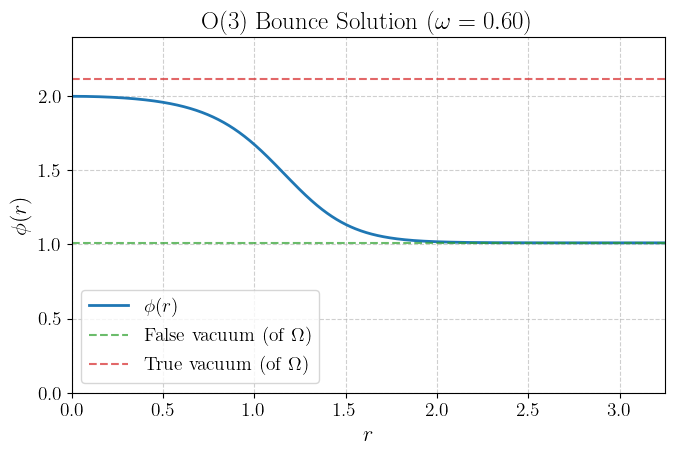

In [37]:
# ============================================================================
# Bounce Solution Solver (Robust Method with Analytical Vacua)
# ============================================================================

from scipy.integrate import solve_ivp

# ============================================================================
# Parameters (modify these to change the calculation)
# ============================================================================
# Use values from configuration by default, or override here:
PHI0_BOUNCE = PHI0    # Field value at center
V1_BOUNCE = V1        # False vacuum (metastable minimum)
V2_BOUNCE = V2        # True vacuum (stable minimum)
OMEGA_BOUNCE = OMEGA  # Chemical potential ω

# Solver parameters:
D = 3                   # Spatial dimension (3 for O(3) symmetry)
R0 = 1e-8              # Initial radius
RMAX = 10.0            # Maximum integration radius
MAX_ITER = 100          # Maximum bisection iterations
VERBOSE = True          # Print progress

# Override with custom values if needed:
OMEGA_BOUNCE = 0.6
# ============================================================================

from scipy.optimize import minimize_scalar

def dV_dphi(phi, phi0, v1, v2):
    """
    First derivative of V(φ) with respect to φ.
    V(φ) = -1/2 + (φ - 1)² [2φ - 5 + (2 - φ)² log((2-φ)²(φ₀-1)²/((φ-1)²(φ₀-2)²))]
    Must be consistent with V_phi: use clipping only for log calculation, not for other terms.
    """
    # Check if input is scalar or array (same as V_phi)
    is_scalar = np.isscalar(phi) or (isinstance(phi, np.ndarray) and phi.ndim == 0)
    phi_arr = np.asarray(phi)
    phi_flat = phi_arr.flatten() if phi_arr.ndim > 0 else np.array([phi_arr])
    
    # Use clipping only for log calculation (consistent with V_phi)
    phi_for_log = np.clip(phi_flat, v1 + 1e-12, v2 - 1e-12)
    
    # Terms using original phi (not clipped) - consistent with V_phi
    term1 = (phi_flat - v1)**2  # (φ - 1)²
    term2 = 2*phi_flat - 5
    
    # Log term uses clipped phi to avoid numerical issues
    log_arg = ((2 - phi_for_log)**2 * (phi0 - v1)**2) / ((phi_for_log - v1)**2 * (phi0 - v2)**2)
    term3 = (2 - phi_for_log)**2 * np.log(log_arg)
    
    # Derivatives
    d_term1 = 2 * (phi_flat - v1)  # d/dφ of (φ-1)² = 2(φ-1)
    d_term2 = 2  # d/dφ of [2φ - 5] = 2
    
    # d/dφ of (2-φ)² log(...)
    # log(...) = 2log(2-φ) + 2log(φ₀-1) - 2log(φ-1) - 2log(φ₀-2)
    # d/dφ log(...) = -2/(2-φ) - 2/(φ-1)
    d_log = -2/(2 - phi_for_log) - 2/(phi_for_log - v1)
    d_term3 = -2*(2 - phi_for_log)*np.log(log_arg) + (2 - phi_for_log)**2 * d_log
    
    # Final derivative: use original phi for main terms, clipped phi only for log-related terms
    dV_flat = d_term1 * (term2 + term3) + term1 * (d_term2 + d_term3)
    
    # Reshape to match input shape (consistent with V_phi)
    if is_scalar:
        dV = float(dV_flat[0])
    else:
        dV = dV_flat.reshape(phi_arr.shape)
    
    # Return as scalar or array
    if isinstance(phi, np.ndarray):
        return dV
    else:
        return float(dV)

def d2V_dphi2(phi, phi0, v1, v2):
    """
    Second derivative of V(φ) with respect to φ.
    Computed numerically for robustness.
    """
    h = 1e-6
    dV_plus = dV_dphi(phi + h, phi0, v1, v2)
    dV_minus = dV_dphi(phi - h, phi0, v1, v2)
    return (dV_plus - dV_minus) / (2 * h)

def dOmega_dphi(phi, phi0, v1, v2, omega):
    """First derivative of grand potential: dΩ/dφ = dV/dφ - ω² φ"""
    dV = dV_dphi(phi, phi0, v1, v2)
    return dV - omega**2 * phi

def d2Omega_dphi2(phi, phi0, v1, v2, omega):
    """Second derivative of grand potential: d²Ω/dφ² = d²V/dφ² - ω²"""
    d2V = d2V_dphi2(phi, phi0, v1, v2)
    return d2V - omega**2

def vacua_of_Omega(phi0, v1, v2, omega):
    """
    Find false and true vacua by solving Ω'(φ) = 0 numerically.
    Returns phi_false (metastable, higher energy) and phi_true (stable, lower energy).
    Uses the same simple approach as cell 5: two separate grids, find minimum in each, then refine.
    Uses Omega_phi from cell 5 to ensure consistency.
    """
    from scipy.optimize import minimize
    
    # Step 1: Find approximate minima using two separate grids (exactly as in cell 5)
    # Search for minima near v1 and v2 using separate fine grids
    phi_grid1 = np.linspace(max(0.5, v1 - 0.2), min(v2 - 0.1, v1 + 0.2), 500)
    phi_grid2 = np.linspace(max(v1 + 0.1, v2 - 0.2), min(2.5, v2 + 0.2), 500)
    Omega_grid1 = np.array([Omega_phi(p, phi0, v1, v2, omega) for p in phi_grid1])
    Omega_grid2 = np.array([Omega_phi(p, phi0, v1, v2, omega) for p in phi_grid2])
    
    # Find the minima from each grid
    idx_min1 = np.argmin(Omega_grid1)
    idx_min2 = np.argmin(Omega_grid2)
    guess1 = phi_grid1[idx_min1]
    guess2 = phi_grid2[idx_min2]
    
    # Step 2: Refine the minima using minimize with initial guesses
    bounds = [(max(0.5, v1 - 0.2), min(2.5, v2 + 0.2))]
    
    try:
        res1 = minimize(
            lambda p: Omega_phi(p[0], phi0, v1, v2, omega),
            x0=[guess1],
            method='L-BFGS-B',
            bounds=bounds,
            options={'ftol': 1e-10}
        )
        phi_min1 = res1.x[0] if res1.success else guess1
    except:
        phi_min1 = guess1
    
    try:
        res2 = minimize(
            lambda p: Omega_phi(p[0], phi0, v1, v2, omega),
            x0=[guess2],
            method='L-BFGS-B',
            bounds=bounds,
            options={'ftol': 1e-10}
        )
        phi_min2 = res2.x[0] if res2.success else guess2
    except:
        phi_min2 = guess2
    
    # Determine which is false (higher energy) and which is true (lower energy)
    Om_min1 = Omega_phi(phi_min1, phi0, v1, v2, omega)
    Om_min2 = Omega_phi(phi_min2, phi0, v1, v2, omega)
    
    if Om_min1 > Om_min2:
        phi_false, phi_true = phi_min1, phi_min2
    else:
        phi_false, phi_true = phi_min2, phi_min1
    
    return phi_false, phi_true


def solve_bounce(phi0, v1, v2, omega, d=3, r0=1e-6, rmax=500.0, max_iter=100, verbose=False, extend_to=None, n_grid_points=1000):
    """
    Robust bounce solution finder using overshoot/undershoot with events.
    
    Uses bisection on φ(0) with events:
    - event_phi_false: φ crosses phi_false (overshoot)
    - event_dphi_zero: φ' crosses zero (undershoot)
    
    Parameters
    ----------
    phi0, v1, v2, omega : float
        Potential parameters: phi0 (field value at center), v1 (false vacuum), v2 (true vacuum), omega (chemical potential)
    d : int
        Spatial dimension (default 3 for O(3) symmetry)
    r0, rmax : float
        Integration range
    max_iter : int
        Maximum bisection iterations
    verbose : bool
        Print progress
    extend_to : float, optional
        If provided, extend solution to this r value after reaching phi_false
        (solution stays constant at phi_false beyond the event point)
    n_grid_points : int
        Number of points in the solution grid (default 1000, increase for higher precision)
        
    Returns
    -------
    r, phi, phi0_init, phi_false, phi_true : arrays/float
        Solution arrays and initial/final values
    """
    # Get vacua numerically
    phi_false, phi_true = vacua_of_Omega(phi0, v1, v2, omega)
    if verbose:
        print(f"Vacua of Ω: phi_false={phi_false:.10f}, phi_true={phi_true:.10f}")

    # Bisection bounds: φ(0) should be between phi_true and phi_false
    phi_L = min(phi_true, phi_false)
    phi_R = max(phi_true, phi_false)
    
    # Events
    def event_phi_false(r, y):
        """Event: φ crosses phi_false going downward (overshoot)"""
        return y[0] - phi_false
    event_phi_false.terminal = True
    event_phi_false.direction = -1  # Only trigger when crossing downward
    
    def event_dphi_zero(r, y):
        """Event: φ' crosses zero (undershoot), but avoid trigger at r=r0"""
        return y[1] if r > 10*r0 else 1.0
    event_dphi_zero.terminal = True
    event_dphi_zero.direction = 1
    
    r_stop = rmax
    sol_final = None
    sol_best = None
    phi0_best = None
    
    for iteration in range(max_iter):
        phi0_init = 0.5 * (phi_L + phi_R)
        
        # ODE: φ'' + (d-1)/r φ' = dΩ/dφ
        sol = solve_ivp(
            fun=lambda r, y: [y[1], -(d-1)/r * y[1] + dOmega_dphi(y[0], phi0, v1, v2, omega)],
            t_span=(r0, rmax),
            y0=[phi0_init, 0.0],
            method='BDF',
            events=[event_phi_false, event_dphi_zero],
            dense_output=True,
            max_step=np.inf,
            atol=1e-8,
            rtol=1e-8
        )
        
        if not sol.success:
            if verbose:
                print(f"  Iteration {iteration}: Integration failed for φ(0)={phi0_init:.6f}")
            # Adjust bounds slightly
            phi_L = phi_L + 0.01 * (phi0_init - phi_L)
            phi_R = phi_R - 0.01 * (phi_R - phi0_init)
            continue
        
        # Check which event fired first
        t_phi_event = sol.t_events[0][0] if sol.t_events[0].size > 0 else np.inf
        t_dphi_event = sol.t_events[1][0] if sol.t_events[1].size > 0 else np.inf
        
        # Get final values for convergence check
        phi_end = sol.y[0, -1]
        dphi_end = sol.y[1, -1]
        
        if t_dphi_event < t_phi_event:
            # Undershoot: φ' hit zero first → φ(0) too small, need to increase
            phi_L = phi0_init
            r_stop = t_dphi_event
            if verbose and iteration % 10 == 0:
                print(f"  Iteration {iteration}: Undershoot, φ(0)={phi0_init:.6f}, φ(∞)={phi_end:.6f}, r_stop={r_stop:.4f}")
        elif t_phi_event < np.inf:
            # Overshoot: φ crossed phi_false going down → φ(0) too large, need to decrease
            phi_R = phi0_init
            r_stop = t_phi_event
            if verbose and iteration % 10 == 0:
                print(f"  Iteration {iteration}: Overshoot, φ(0)={phi0_init:.6f}, φ(∞)={phi_end:.6f}, r_stop={r_stop:.4f}")
        else:
            # No event fired: check if we're close to phi_false
            if phi_end > phi_false:
                # Still above phi_false → undershoot, need to increase φ(0)
                phi_L = phi0_init
                if verbose and iteration % 10 == 0:
                    print(f"  Iteration {iteration}: No event, above false, φ(0)={phi0_init:.6f}, φ(∞)={phi_end:.6f}")
            else:
                # Below phi_false → overshoot, need to decrease φ(0)
                phi_R = phi0_init
                if verbose and iteration % 10 == 0:
                    print(f"  Iteration {iteration}: No event, below false, φ(0)={phi0_init:.6f}, φ(∞)={phi_end:.6f}")
        
        sol_final = sol.sol
        sol_best = sol
        phi0_best = phi0_init
        
        # Check convergence: bounds are close
        if abs(phi_R - phi_L) < 1e-8:
            if verbose:
                print(f"  Converged after {iteration+1} iterations: φ(0)={phi0_init:.6f}, φ(∞)={phi_end:.6f}, φ'(∞)={dphi_end:.3e}")
            break
    
    if sol_best is None or not sol_best.success:
        if verbose:
            print("  Failed to find solution")
        return None, None, None, None, None
    
    # Extract solution using dense_output on a grid
    # The solution stops when φ' changes sign (event_dphi_zero) or when it reaches phi_false (event_phi_false)
    r_end = sol_best.t[-1]
    
    # Create a grid and evaluate using dense_output
    r_grid = np.linspace(r0, r_end, n_grid_points)
    phi_grid = sol_best.sol(r_grid)[0]
    
    # Optionally extend solution beyond r_end if extend_to is specified
    if extend_to is not None and extend_to > r_end:
        # Continue ODE integration from r_end to extend_to using final conditions
        phi_end_val = sol_best.y[0, -1]
        dphi_end_val = sol_best.y[1, -1]
        
        # Continue integration without events (just integrate to extend_to)
        sol_extend = solve_ivp(
            fun=lambda r, y: [y[1], -(d-1)/r * y[1] + dOmega_dphi(y[0], phi0, v1, v2, omega)],
            t_span=(r_end, extend_to),
            y0=[phi_end_val, dphi_end_val],
            method='BDF',
            dense_output=True,
            max_step=np.inf,
            atol=1e-8,
            rtol=1e-8
        )
        
        if sol_extend.success:
            # Number of points for extension (proportional to length)
            n_extend = int(n_grid_points * (extend_to - r_end) / (r_end - r0))
            n_extend = max(200, min(n_extend, 1000))  # Between 200 and 1000 points
            r_extend = np.linspace(r_end, extend_to, n_extend)
            phi_extend = sol_extend.sol(r_extend)[0]
            
            # Combine original and extended solution (skip duplicate point at r_end)
            r_grid = np.concatenate([r_grid, r_extend[1:]])
            phi_grid = np.concatenate([phi_grid, phi_extend[1:]])
        else:
            # Fallback: if extension fails, use constant value
            if verbose:
                print(f"  Warning: Extension integration failed, using constant phi_false")
            n_extend = int(n_grid_points * (extend_to - r_end) / (r_end - r0))
            n_extend = max(200, min(n_extend, 1000))
            r_extend = np.linspace(r_end, extend_to, n_extend)
            phi_extend = np.full_like(r_extend, phi_false)
            r_grid = np.concatenate([r_grid, r_extend[1:]])
            phi_grid = np.concatenate([phi_grid, phi_extend[1:]])
    
    phi0_final = float(phi0_best) if phi0_best is not None else float(phi0)
    
    return r_grid, phi_grid, phi0_final, phi_false, phi_true

# Solve bounce with chosen parameters
print("Solving O(3) bounce solution...")
print(f"Parameters: φ₀={PHI0_BOUNCE}, v1={V1_BOUNCE}, v2={V2_BOUNCE}, ω={OMEGA_BOUNCE}")
print(f"Analytical action (d=4, Q=0): S₀ = {S0_analytical(PHI0_BOUNCE):.6f}")
r_bounce, phi_bounce, phi0_bounce, phi_false_bounce, phi_true_bounce = solve_bounce(
    PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE, 
    d=D, r0=R0, rmax=RMAX, max_iter=MAX_ITER, verbose=VERBOSE
)

if r_bounce is not None:
    print(f"\nBounce solution found:")
    print(f"  φ(0) = {phi0_bounce:.6f}")
    print(f"  φ(∞) ≈ {phi_bounce[-1]:.6f} (target false = {phi_false_bounce:.6f})")
    print(f"  r_max = {r_bounce[-1]:.2f}")
    print(f"  Number of points: {len(r_bounce)}")
    print(f"  phi range: [{phi_bounce.min():.6f}, {phi_bounce.max():.6f}]")
    
    # Update phi_false and phi_true with analytical values
    phi_false = phi_false_bounce
    phi_true = phi_true_bounce
    
    # Plot bounce solution
    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.plot(r_bounce, phi_bounce, lw=2, color='C0', label=r"$\phi(r)$")
    ax.axhline(phi_false, color='C2', ls='--', lw=1.5, label=rf"False vacuum (of $\Omega$)", alpha=0.7)
    ax.axhline(phi_true, color='C3', ls='--', lw=1.5, label=rf"True vacuum (of $\Omega$)", alpha=0.7)
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$\phi(r)$")
    ax.set_xlim(0, r_bounce[-1])
    ax.set_ylim(0, phi_bounce.max()*1.2)
    ax.set_title(rf"O(3) Bounce Solution ($\omega = {OMEGA_BOUNCE:.2f}$)")
    ax.legend()
    ax.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Failed to find bounce solution.")

## Energy and Charge Densities

For the bounce solution, we compute the **energy and charge densities** by dividing the total values by the volume of the sphere. These densities characterize the bubble solution and show how it depends on the chemical potential $\omega$.

**Energy density** (above the false vacuum):
$$\rho_E = \frac{E}{V} = \frac{4\pi \int_0^{r_{\max}} dr \, r^2 \left[ \frac{1}{2}\left(\frac{d\phi}{dr}\right)^2 + \Omega(\phi) - \Omega(\phi_{\text{false}}) \right]}{\frac{4}{3}\pi r_{\max}^3}$$

The energy $E$ measures the cost of creating the bubble above the false vacuum background. It includes:
- **Kinetic energy**: $\frac{1}{2}\left(\frac{d\phi}{dr}\right)^2$ from the field gradient
- **Potential energy**: $\Omega(\phi) - \Omega(\phi_{\text{false}})$ relative to the false vacuum

**Charge density** (from the finite density term):
$$\rho_Q = \frac{Q}{V} = \frac{4\pi \omega \int_0^{r_{\max}} dr \, r^2 \phi^2}{\frac{4}{3}\pi r_{\max}^3}$$

where $V = \frac{4}{3}\pi r_{\max}^3$ is the volume of the sphere of radius $r_{\max}$ (the maximum radius where the solution is computed, determined by when $\phi'(r)$ changes sign).

The charge $Q$ arises from the $-\frac{1}{2}\omega^2\phi^2$ term in the grand potential, which breaks the symmetry and introduces a conserved charge. The charge density $\rho_Q$ quantifies how much charge is carried by the bubble per unit volume.

**Physical Interpretation:**

- **Energy density** $\rho_E$: Determines the suppression of the tunneling rate. Higher energy means slower tunneling.
- **Charge density** $\rho_Q$: Measures the charge carried by the bubble. As $\omega$ increases, the charge density grows, and the bubble becomes more "charged".

In [38]:
# ============================================================================
# Compute Energy and Charge
# ============================================================================

def compute_energy(r, phi, phi0, v1, v2, omega, phi_false):
    """
    Compute energy: E = 4π ∫ dr r² [ ½ (dφ/dr)² + Ω(φ) - Ω(φ_false) ]
    """
    # Compute derivative
    dphi_dr = np.gradient(phi, r, edge_order=2)
    dphi_dr[0] = 0.0  # Regularity at origin
    
    # Compute integrand using Omega function (same as in solve_bounce)
    Omega_phi_vals = np.array([Omega(phi_i, phi0, v1, v2, omega) for phi_i in phi])
    Omega_false = Omega(phi_false, phi0, v1, v2, omega)
    
    integrand = 0.5 * dphi_dr**2 + (Omega_phi_vals - Omega_false)
    energy = 4.0 * np.pi * np.trapezoid(r**2 * integrand, r)
    return energy

def compute_charge(r, phi, omega):
    """
    Compute charge: Q = 4π ω ∫ dr r² φ²
    """
    integral = np.trapezoid(r**2 * phi**2, r)
    return 4.0 * np.pi * omega * integral

def compute_energy_density(r, phi, phi0, v1, v2, omega, phi_false):
    """
    Compute energy density: ρ_E = E/V where
    E = 4π ∫ dr r² [ ½ (dφ/dr)² + Ω(φ) - Ω(φ_false) ]
    V = (4/3)π r_max³
    """
    energy = compute_energy(r, phi, phi0, v1, v2, omega, phi_false)
    r_max = r[-1]
    volume = (4.0 / 3.0) * np.pi * r_max**3
    rho_E = energy / volume
    return rho_E

def compute_charge_density(r, phi, omega):
    """
    Compute charge density: ρ_Q = Q/V where
    Q = 4π ω ∫ dr r² φ²
    V = (4/3)π r_max³
    """
    charge = compute_charge(r, phi, omega)
    r_max = r[-1]
    volume = (4.0 / 3.0) * np.pi * r_max**3
    rho_Q = charge / volume
    return rho_Q

if r_bounce is not None:
    # Use the bounce parameters
    E_bounce = compute_energy(r_bounce, phi_bounce, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE, phi_false_bounce)
    Q_bounce = compute_charge(r_bounce, phi_bounce, OMEGA_BOUNCE)
    
    print(f"Bounce solution observables:")
    print(f"  Energy: E = {E_bounce:.6f}")
    print(f"  Charge: Q = {Q_bounce:.6f}")
    print(f"  E/Q = {E_bounce/Q_bounce:.6f}")

Bounce solution observables:
  Energy: E = 4.785139
  Charge: Q = 99.739595
  E/Q = 0.047976


## Charge and Energy Density vs Omega Scan

We scan over the chemical potential $\omega$ to study how the bubble solution depends on finite density effects. The bounce solution exists only when the grand potential $\Omega(\phi) = V(\phi) - \frac{1}{2}\omega^2\phi^2$ has two distinct minima.

**Range of Validity:**

- $\omega_{\min} = 0$: At zero chemical potential, we recover the standard vacuum decay case. The analytical action $S_0$ provides a reference for $d=4$ and $Q=0$.
- $\omega_{\max}$: Maximum value where two minima still exist. Beyond this, the $\omega^2$ term becomes too large and destroys one of the minima, making tunneling impossible.

**Adaptive r₀ Selection:**

For each $\omega$, we use an adaptive binary search to find the optimal initial radius $r_0$:
- Start from $r_0 = 10^{-10}$ (very small, needed for small $\omega$)
- If the solution doesn't converge (either $|\phi(\infty) - \phi_{\text{false}}| > 10^{-3}$ or $|\phi'(\infty)| > 10^{-3}$), we increase $r_0$
- Use binary search to find the smallest $r_0$ that gives a convergent solution
- This ensures accurate solutions for both small and large values of $\omega$

**Output:**

For each $\omega$ in the valid range, we compute:
- The bounce solution $\phi(r)$
- Charge density $\rho_Q(\omega)$
- Energy density $\rho_E(\omega)$

These quantities show how finite density (non-zero $\omega$) affects the bubble nucleation process.

In [39]:
# ============================================================================
# Find Omega Range with Two Minima
# ============================================================================

def has_two_minima(phi0, v1, v2, omega):
    """
    Check if the grand potential has two distinct minima using numerical method.
    """
    try:
        phi_false, phi_true = vacua_of_Omega(phi0, v1, v2, omega)
        return True
    except RuntimeError:
        return False

# ============================================================================
# Scan Parameters (for higher precision)
# ============================================================================
SCAN_RMAX = 1000.0        # Maximum integration radius for scan
SCAN_MAX_ITER = 150       # Maximum bisection iterations for scan
SCAN_N_POINTS = 100       # Number of omega points in scan
SCAN_GRID_POINTS = 2000   # Number of points in solution grid (for integration)

# Find maximum omega where two minima exist (with higher precision)
print("Finding maximum omega with two minima...")
omega_test = np.linspace(0.0, 2.0, 500)  # More points for better precision
omega_max = 0.0
for om in omega_test:
    if has_two_minima(phi0, v1, v2, om):
        omega_max = om
    else:
        break

print(f"Omega range with two minima: [0, {omega_max:.6f}]")

# Scan over omega
print(f"\nScanning over omega in [0, {omega_max:.6f}]...")
print(f"Scan parameters: RMAX={SCAN_RMAX}, max_iter={SCAN_MAX_ITER}, n_points={SCAN_N_POINTS}")
n_omega = SCAN_N_POINTS
omega_scan = np.linspace(0.01, omega_max * 0.95, n_omega)  # Avoid boundaries
Q_vals = []
E_vals = []
omega_valid = []

def find_optimal_r0(phi0, v1, v2, omega, r0_min=1e-10, r0_max=1e-2, max_bisection_iter=20):
    """
    Find optimal r0 using binary search that gives convergent solution.
    Returns (r0_optimal, r_b, phi_b, phi0_b, phi_false_om, phi_true_om) or None if not found.
    """
    r0_low = r0_min
    r0_high = r0_max
    best_solution = None
    best_r0 = None
    
    # First, try to find a working r0 by scanning coarsely
    r0_test_values = np.logspace(np.log10(r0_min), np.log10(r0_max), 10)
    working_r0 = None
    
    for r0_test in r0_test_values:
        try:
            r_b, phi_b, phi0_b, phi_false_om, phi_true_om = solve_bounce(
                phi0, v1, v2, omega, 
                d=3, r0=r0_test, rmax=SCAN_RMAX, 
                max_iter=SCAN_MAX_ITER, verbose=False,
                n_grid_points=SCAN_GRID_POINTS
            )
            
            if r_b is not None and len(r_b) > 10:
                # Check convergence: both φ(∞) and φ'(∞) must be small
                phi_end = phi_b[-1]
                dphi_dr = np.gradient(phi_b, r_b, edge_order=2)
                dphi_end = dphi_dr[-1]
                
                phi_error = abs(phi_end - phi_false_om)
                dphi_error = abs(dphi_end)
                
                if phi_error < 1e-3 and dphi_error < 1e-3:
                    working_r0 = r0_test
                    best_solution = (r_b, phi_b, phi0_b, phi_false_om, phi_true_om)
                    best_r0 = r0_test
                    break
        except (RuntimeError, ValueError):
            continue
    
    if working_r0 is None:
        return None
    
    # Now do binary search to find the smallest r0 that works
    r0_low = r0_min
    r0_high = working_r0
    
    for bisect_iter in range(max_bisection_iter):
        r0_mid = 0.5 * (r0_low + r0_high)
        
        try:
            r_b, phi_b, phi0_b, phi_false_om, phi_true_om = solve_bounce(
                phi0, v1, v2, omega, 
                d=3, r0=r0_mid, rmax=SCAN_RMAX, 
                max_iter=SCAN_MAX_ITER, verbose=False,
                n_grid_points=SCAN_GRID_POINTS
            )
            
            if r_b is not None and len(r_b) > 10:
                phi_end = phi_b[-1]
                dphi_dr = np.gradient(phi_b, r_b, edge_order=2)
                dphi_end = dphi_dr[-1]
                
                phi_error = abs(phi_end - phi_false_om)
                dphi_error = abs(dphi_end)
                
                if phi_error < 1e-3 and dphi_error < 1e-3:
                    # This r0 works, try smaller
                    best_solution = (r_b, phi_b, phi0_b, phi_false_om, phi_true_om)
                    best_r0 = r0_mid
                    r0_high = r0_mid
                else:
                    # This r0 doesn't work, need larger
                    r0_low = r0_mid
            else:
                # Invalid solution, need larger r0
                r0_low = r0_mid
                
        except (RuntimeError, ValueError):
            # Error, need larger r0
            r0_low = r0_mid
        
        # Check convergence of binary search
        if abs(r0_high - r0_low) / r0_high < 0.1:  # Within 10% relative error
            break
    
    if best_solution is not None:
        return (best_r0,) + best_solution
    return None

for i, om in enumerate(omega_scan):
    if i % 10 == 0:
        print(f"  Processing omega = {om:.6f} ({i+1}/{n_omega})...")
    
    # Find optimal r0 using binary search
    result = find_optimal_r0(phi0, v1, v2, om, r0_min=1e-10, r0_max=1e-2)
    
    if result is not None:
        r0_optimal, r_b, phi_b, phi0_b, phi_false_om, phi_true_om = result
        
        # Double-check convergence
        phi_end = phi_b[-1]
        dphi_dr = np.gradient(phi_b, r_b, edge_order=2)
        dphi_end = dphi_dr[-1]
        phi_error = abs(phi_end - phi_false_om)
        dphi_error = abs(dphi_end)
        
        if phi_error < 1e-3 and dphi_error < 1e-3:
            rho_Q = compute_charge_density(r_b, phi_b, om)
            rho_E = compute_energy_density(r_b, phi_b, phi0, v1, v2, om, phi_false_om)
            Q_vals.append(rho_Q)
            E_vals.append(rho_E)
            omega_valid.append(om)
            if i % 10 == 0 and r0_optimal > 1e-9:
                print(f"    Converged with r0={r0_optimal:.2e} (φ error: {phi_error:.2e}, φ' error: {dphi_error:.2e})")
        else:
            if i % 10 == 0:
                print(f"    Solution found but not converged (φ error: {phi_error:.2e}, φ' error: {dphi_error:.2e})")
    else:
        if i % 10 == 0:
            print(f"    No convergent solution found for omega = {om:.6f}")

Q_vals = np.array(Q_vals)
E_vals = np.array(E_vals)
omega_valid = np.array(omega_valid)

print(f"\nScan complete: {len(omega_valid)} successful solutions")

Finding maximum omega with two minima...
Omega range with two minima: [0, 2.000000]

Scanning over omega in [0, 2.000000]...
Scan parameters: RMAX=1000.0, max_iter=150, n_points=100
  Processing omega = 0.010000 (1/100)...


KeyboardInterrupt: 

## Charge and Energy Density vs Omega Plot

The charge density $\rho_Q(\omega)$ and energy density $\rho_E(\omega)$ show how the bubble solution depends on the chemical potential $\omega$.

**Key Features:**

- **At $\omega = 0$**: There is no charge ($\rho_Q = 0$), and we recover the standard vacuum decay. The energy density $\rho_E$ at $\omega = 0$ can be compared with the analytical action $S_0$ for $d=4$ (though we compute in $d=3$ here).

- **As $\omega$ increases**: 
  - The charge density $\rho_Q(\omega)$ grows, indicating that the bubble carries more charge
  - The energy density $\rho_E(\omega)$ changes, showing how finite density affects the tunneling barrier
  - The grand potential $\Omega(\phi)$ is increasingly modified, shifting the minima away from $\phi = 1$ and $\phi = 2$

- **At $\omega_{\max}$**: The maximum value where two minima still exist. Beyond this point, the $\omega^2$ term becomes dominant and destroys the barrier between vacua.

**Physical Interpretation:**

The curves $\rho_Q(\omega)$ and $\rho_E(\omega)$ characterize how finite density (non-zero chemical potential) modifies the bubble nucleation process. This is relevant for understanding vacuum decay in environments with finite particle density, such as in early universe cosmology or high-density matter systems.

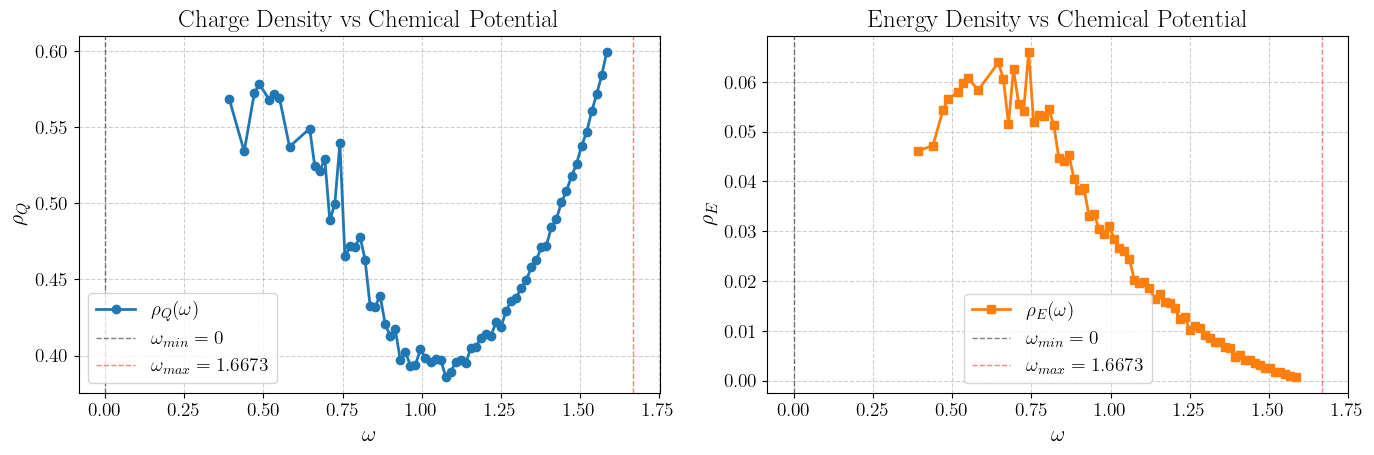


Summary:
  ω range: [0, 1.6673]
  ρ_Q range: [3.862312e-01, 5.994220e-01]
  ρ_E range: [8.079563e-04, 6.600642e-02]


In [40]:
# Plot charge vs omega
if len(omega_valid) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))
    
    # Charge vs omega
    ax1.plot(omega_valid, Q_vals, 'o-', lw=2, markersize=6, color='C0', label=r"$Q(\omega)$")
    ax1.set_xlabel(r"$\omega$")
    ax1.set_ylabel(r"$Q$")
    ax1.set_title("Charge vs Chemical Potential")
    ax1.axvline(0, color='k', ls='--', lw=1, alpha=0.5, label=rf"$\omega_{{min}} = 0$")
    ax1.axvline(omega_max, color='r', ls='--', lw=1, alpha=0.5, label=rf"$\omega_{{max}} = {omega_max:.4f}$")
    ax1.legend()
    ax1.grid(True, ls="--", alpha=0.6)
    
    # Energy vs omega
    ax2.plot(omega_valid, E_vals, 's-', lw=2, markersize=6, color='C1', label=r"$E(\omega)$")
    ax2.set_xlabel(r"$\omega$")
    ax2.set_ylabel(r"$E$")
    ax2.set_title("Energy vs Chemical Potential")
    ax2.axvline(0, color='k', ls='--', lw=1, alpha=0.5, label=rf"$\omega_{{min}} = 0$")
    ax2.axvline(omega_max, color='r', ls='--', lw=1, alpha=0.5, label=rf"$\omega_{{max}} = {omega_max:.4f}$")
    ax2.legend()
    ax2.grid(True, ls="--", alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nSummary:")
    print(f"  ω range: [0, {omega_max:.4f}]")
    print(f"  Q range: [{Q_vals.min():.4f}, {Q_vals.max():.4f}]")
    print(f"  E range: [{E_vals.min():.4f}, {E_vals.max():.4f}]")
else:
    print("No valid solutions found for plotting.")

In [23]:
print(Q_vals)
print(omega_valid)

[0.06152983 0.33108117 0.45274108 0.49978714 0.5166007  0.51082433
 0.5211436  0.27654977 0.64357388 0.68429544 0.57403847 0.55301136
 0.56871332 0.68986803 0.59228526 0.59485743 0.67238299 0.57226455
 0.57835483 0.56456246 0.56780877 0.57201669 0.55428638 0.56963582
 0.75809264 0.55889252 0.91549006 0.55233485 0.56189432 0.53152219
 0.52113148 0.5193712  0.99746956 0.49978463 0.9500149  0.50162505
 1.04473322 0.48711236 1.12672353 0.88452683 0.43269526 0.43222576
 0.43926148 1.23341481 0.41307572 0.41741362 0.39691035 0.40257616
 0.39348394 0.39396445 0.40402181 0.39846262 0.39564011 0.39807258
 0.39744317 0.38623121 0.38932964 0.3956426  0.39725445 0.39497531
 0.40510602 0.40560794 0.41163906 0.41418442 0.41300466 0.42188827
 0.41877123 0.42934862 0.4359727  0.43807535 0.4441281  0.44933628
 0.45789138 0.46277547 0.4710594  0.4722272  0.48427504 0.48969887
 0.50053838 0.50818477 0.51775952 0.52582908 0.53783068 0.54670123
 0.56031503 0.57171012 0.5841082  0.599422  ]
[0.12129066 0.15